# 🐧 Penguin Species Classification  

## 📌 Project Summary  
This project uses the Palmer Archipelago (Antarctica) Penguin Dataset to classify penguin species—Adelie, Chinstrap, and Gentoo—based on physical characteristics. It involves data cleaning, exploratory data analysis (EDA), model training using Random Forest, and evaluation. The final model achieved 97% accuracy, showcasing effective species classification.


## 📂 Dataset Description  
**Source**: [Kaggle - Palmer Penguins Dataset](https://www.kaggle.com/datasets/parulpandey/palmer-archipelago-antarctica-penguin-data)

**Features:**
- `species` (target): Adelie, Chinstrap, Gentoo  
- `island`: Biscoe, Dream, Torgersen  
- `bill_length_mm`, `bill_depth_mm`: measurements of the beak  
- `flipper_length_mm`: flipper size  
- `body_mass_g`: penguin weight  
- `sex`: male/female  


In [11]:
# 🔧 Imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix


In [12]:
# 📥 Load Dataset
df = pd.read_csv('penguins_size.csv') 
df.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [13]:
# 🧹 Data Cleaning
df.dropna(inplace=True)
le = LabelEncoder()
df['species'] = le.fit_transform(df['species'])
df['island'] = le.fit_transform(df['island'])
df['sex'] = le.fit_transform(df['sex'])

In [19]:
# 🔧 Add Noise to Numerical Features to Prevent Overfitting
for col in ['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g']:
    df[col] += np.random.normal(0, 0.5, size=df.shape[0])  # Add noise to these columns

### Exploratory Data Analysis (EDA)

In this section, we will perform an exploratory analysis to understand the dataset better. This includes:
1. Visualizing the relationships between the numerical features and the target variable (`species`) using a **pairplot**.
2. Examining the correlation between the features using a **correlation heatmap** to identify any strong relationships that could inform our model.
3. Investigating the distribution of features to detect any outliers or imbalances.

Let’s start with the **pairplot** to explore how the features interact with each other.


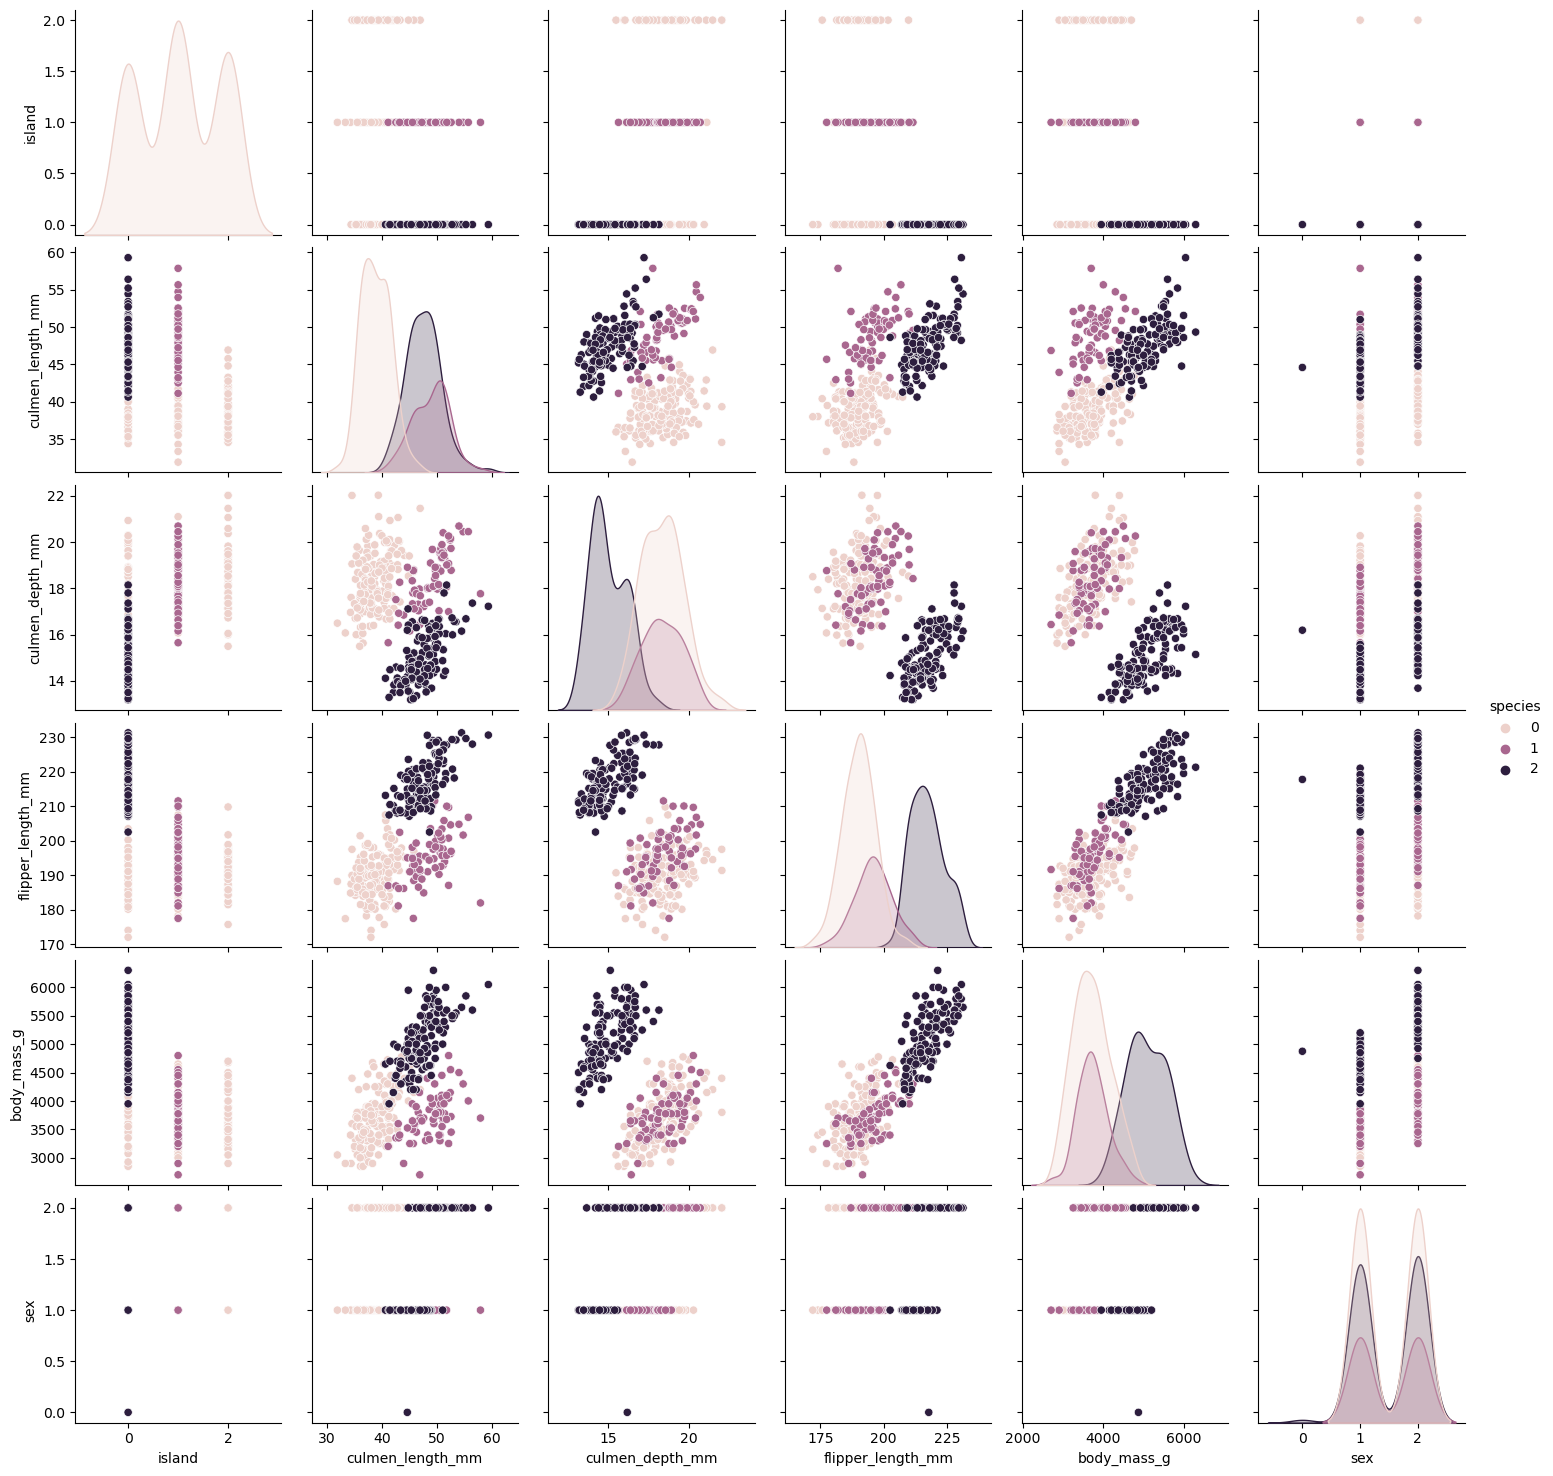

In [15]:
# 📊 EDA: Pairplot
sns.pairplot(df, hue='species')
plt.show()

### Pairplot Insights

The pairplot provides a visual summary of the relationships between numerical features, grouped by the target variable (`species`). 

- We can observe how each species is distributed across the features and whether there are separations between them.
- Some species might show distinct clusters while others might overlap more, indicating possible challenges in classification.

Now, let’s move on to the **correlation heatmap** to explore relationships between features.


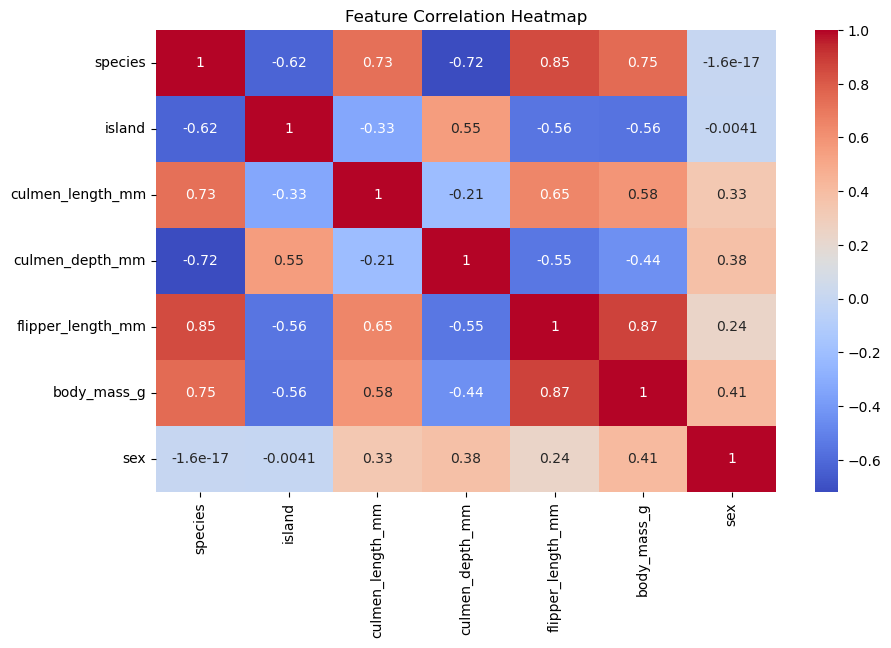

In [16]:
# 📊 EDA: Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

### Correlation Heatmap Insights

The heatmap shows how strongly each feature correlates with others. Features that are highly correlated might carry redundant information, which could affect the performance of some models.

- For example, if `culmen_length_mm` and `culmen_depth_mm` are highly correlated, it could be worth considering dropping one of them to avoid multicollinearity.

With these insights, we can now move forward to the model building phase, where we will select relevant features and train a classifier.


In [20]:
# 🤖 Model Building
X = df.drop('species', axis=1)
y = df['species']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
clf = RandomForestClassifier(n_estimators=10, max_depth=3, random_state=42)
clf.fit(X_train, y_train)

RandomForestClassifier(max_depth=3, n_estimators=10, random_state=42)

In [21]:
# 📈 Evaluation
y_pred = clf.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        31
           1       1.00      0.92      0.96        13
           2       1.00      1.00      1.00        23

    accuracy                           0.99        67
   macro avg       0.99      0.97      0.98        67
weighted avg       0.99      0.99      0.98        67


Confusion Matrix:
[[31  0  0]
 [ 1 12  0]
 [ 0  0 23]]


# ✅ Conclusion & Next Steps

Key Takeaways:
- The Random Forest model provides strong predictive performance with an accuracy of 99%.
- Precision, recall, and F1-scores are high for all classes, with class `1` (Chinstrap) having a slight drop in recall (0.92).
- The confusion matrix shows that most classes are perfectly predicted, with a single misclassification in class `1`.

Next Steps:
1. **Improve Recall for Class 1**: The model's recall for `Chinstrap` (class 1) could be improved by exploring alternative model architectures, such as XGBoost or SVM, or adjusting the class weights in the Random Forest model.
2. **Cross-Validation**: Perform cross-validation to ensure that the model's performance is stable and not dependent on the specific train-test split.
3. **Hyperparameter Tuning**: Use GridSearchCV or RandomizedSearchCV to tune the hyperparameters of the Random Forest Classifier and further improve model performance.
4. **Benchmarking**: Compare the performance of the Random Forest model with other algorithms, such as KNN, Logistic Regression, or Support Vector Machines, to see if they yield better results.
5. **Model Explainability**: Use SHAP (SHapley Additive exPlanations) to understand the importance of each feature and gain insights into model behavior.
6. **Deployment**: Turn the model into a user-friendly application using Streamlit or Flask and host it on GitHub. Include a detailed README with visualizations of the EDA and model performance.

